In [1]:
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import matplotlib.lines as mlines
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.gridspec import GridSpec

from scipy.optimize import minimize_scalar

from AbelianCT_Potential import Abelian_Model


Tree-level vev:        v     = 245.1775 GeV
One-loop minimum:      phi*  = 245.1775 GeV
Residual shift:        |v - phi*| = 5.69e-07 GeV
Vtot'(v)  = 1.96e-02  (should be ~0)
Vtot''(v) = 15629.1200 vs tree-level mh^2 = 15629.1200


## Define the Model

In [3]:
# Parameters: strong FOPT regime (large g/sqrt(lam) ratio)
lam, mu, g = 0.05, 50.0, 1.0

model = Abelian_Model(lam, mu, g)

# Analytic expectations
v_tree  = mu / np.sqrt(lam)
mh_tree = np.sqrt(2.0) * mu
mA_tree = g * v_tree
print(f"Tree-level vev :  v  = {v_tree:.3f} GeV")
print(f"Tree-level Higgs: mh = {mh_tree:.3f} GeV")
print(f"Tree-level gauge: mA = {mA_tree:.3f} GeV")

# Numerical vev from Vtot(T=0)
T_eps = 1e-6  # numerically zero, avoids division by T=0

res = minimize_scalar(
    lambda phi: model.Vtot(np.array([[phi]]), T_eps).item(),
    bounds=(50, 350),
    method='bounded'
)
v_num = res.x
print(f"\nNumerical vev (Vtot, T=0): {v_num:.3f} GeV")
print(f"CW shift: {abs(v_num - v_tree)/v_tree * 100:.3f}%")

Tree-level vev :  v  = 223.607 GeV
Tree-level Higgs: mh = 70.711 GeV
Tree-level gauge: mA = 223.607 GeV

Numerical vev (Vtot, T=0): 223.607 GeV
CW shift: 0.000%


## Coleman Weinberg ($T=0$)

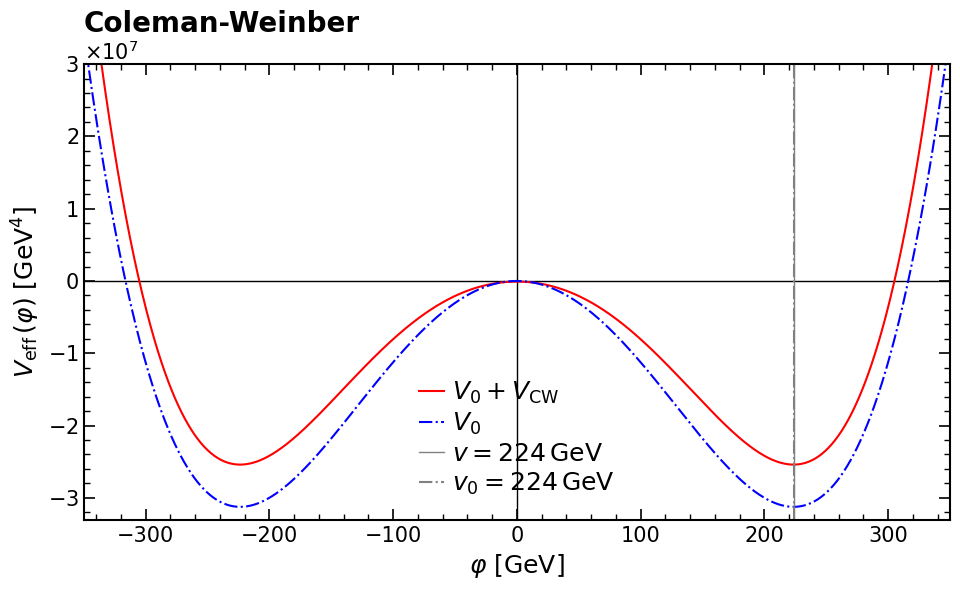

In [11]:
phi_vals = np.linspace(-500, 500, 1500)
X        = phi_vals[:, np.newaxis] 

V_tree   = model.V0(X)
V_tot_0  = model.Vtot(X, 0.0)

fig, ax = plt.subplots(figsize=(9.7, 6))

ax.axhline(0, color='k', lw=1, ls='-')
ax.axvline(0, color='k', lw=1, ls='-')

ax.plot(phi_vals, V_tot_0, label=r'$V_0 + V_\mathrm{CW}$', color='r', lw=1.5, ls='-')
ax.plot(phi_vals, V_tree, label=r'$V_0$', color='b', lw=1.5, ls='-.')

ax.axvline(v_num, label=rf'$v={float(np.squeeze(v_num)):.0f} \, \mathrm{{GeV}}$', color='gray', lw=1.0, ls='-', alpha=1)
ax.axvline(v_tree, label=rf'$v_0={v_tree:.0f} \, \mathrm{{GeV}}$', color='gray', lw=1.5, ls='-.', alpha=1)

ax.set_xlim(-350, 350)
ax.set_ylim(-3.3e7,3e7)

ax.set_xlabel(r'$\varphi$ $\left[\mathrm{GeV}\right]$', fontsize=18)
ax.set_ylabel(r'$V_\mathrm{eff}\,(\varphi)$ $\left[\mathrm{GeV^4}\right]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in', length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()
ax.tick_params(axis='x', which='major', pad=5)

plt.legend(fontsize=18, frameon=True, fancybox=False, ,
               ncol = 1, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.title(r"Coleman-Weinber", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig("figures\AbelianCT_CW.pdf", format="pdf", bbox_inches="tight")

plt.show()

## Thermal Evolution

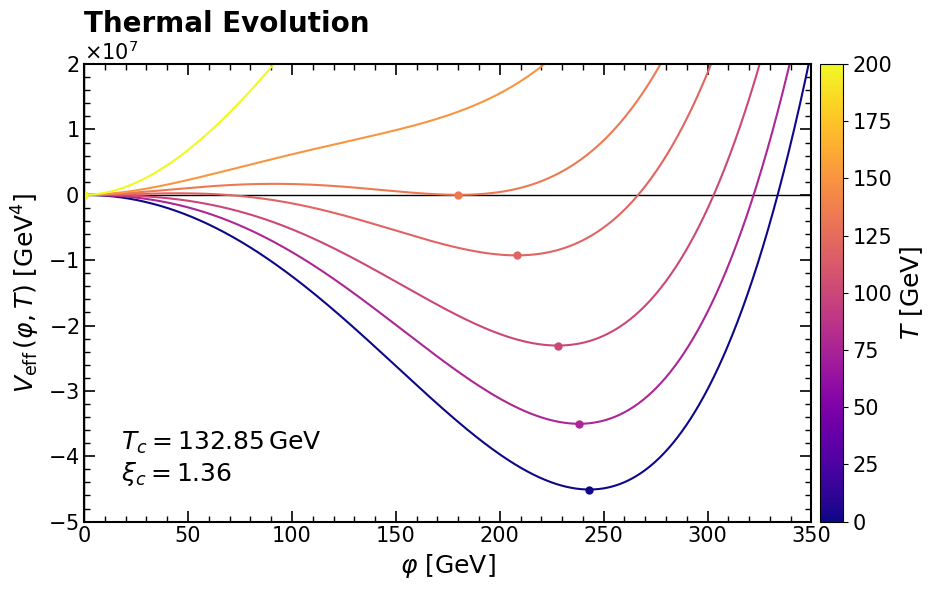

In [41]:
T_vals   = np.array([1e-6, 77, 100, 120, 132.85, 150, 200])
phi_vals = np.linspace(-10,400,1500)
X        = phi_vals[:, np.newaxis]

# Colormap
cmap  = plt.cm.plasma
norm  = Normalize(vmin=0, vmax=T_vals.max())
sm    = ScalarMappable(cmap=cmap, norm=norm)

fig, ax = plt.subplots(figsize=(9.7, 6))

ax.axhline(0, color='k', lw=1, ls='-')
ax.axvline(0, color='k', lw=1, ls='-')

for T in T_vals:
    V = model.Vtot(X, T)
    V_norm = V - model.Vtot(np.array([[0.0]]), T)
    color = cmap(norm(T))
    label = r'$T = 0$' if T < 1 else rf'$T = {T:.0f}$ GeV'
    ax.plot(phi_vals, V_norm, color=color, lw=1.5, label=label)

    # Mark the minimum of the broken phase
    mask = phi_vals > 0          # Impose Positive vev
    idx  = np.argmin(V[mask])
    phi_min = phi_vals[mask][idx]
    V_min   = V[mask][idx]
    ax.plot(phi_min, V_min-model.Vtot(np.array([[0.0]]), T), 'o', color=color, ms=5)

ax.set_xlim(0, 350)
ax.set_ylim(-5e7,2e7)

ax.set_xlabel(r'$\varphi$ $\left[\mathrm{GeV}\right]$', fontsize=18)
ax.set_ylabel(r'$V_\mathrm{eff}\,(\varphi, T)$ $\left[\mathrm{GeV^4}\right]$', fontsize=18)

ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

# Configure ticks
ax.tick_params(axis='both', which='major', direction='in', length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$T\ [\mathrm{GeV}]$', fontsize=18)
cbar.ax.tick_params(labelsize=15)

annotation = (
    rf"$T_c   = 132.85 \, \mathrm{{GeV}}$"  "\n"
    rf"$\xi_c = 1.36$"
)
ax.text(
    0.05, 0.2, annotation,
    transform=ax.transAxes,
    fontsize=18,
    verticalalignment='top',
    horizontalalignment='left'
)

plt.title(r"Thermal Evolution", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig("figures\Abelian_Thermal.pdf", format="pdf", bbox_inches="tight")

plt.show()

## Phase Transition

In [43]:
model.findAllTransitions()
print()
print("=======================================================")
print("The model has", len(model.TnTrans), "transition(s)")
print("=======================================================")

Tracing phase starting at x = [243.11675206] ; t = 0.0
Tracing minimum up
traceMinimum t0 = 0
.....................................................................................................................................
Tracing phase starting at x = [8.67361738e-19] ; t = 138.98910811349575
Tracing minimum down
traceMinimum t0 = 138.989
..............................
Tracing minimum up
traceMinimum t0 = 138.989
..........
Tunneling from phase 1 to phase 0 at T=105.6344
high_vev = [0.00208791]
low_vev = [223.77473624]
Path deformation converged. 1 steps. fRatio = 5.17554e-14
Tunneling from phase 1 to phase 0 at T=105.6349
high_vev = [0.00080552]
low_vev = [223.77433214]
Path deformation converged. 1 steps. fRatio = 7.74562e-14
Tunneling from phase 1 to phase 0 at T=121.8111
high_vev = [4.11996826e-18]
low_vev = [205.42744227]
Path deformation converged. 1 steps. fRatio = 6.13289e-14
Tunneling from phase 1 to phase 0 at T=129.8992
high_vev = [-2.60208521e-17]
low_vev = [189.08233

### Critical Temperature $T_C$

In [45]:
# Find T_c & Transition strength
for i, trans in enumerate(model.TnTrans):
    Tc   = trans["crit_trans"]['Tcrit']
    high = trans["crit_trans"]['high_vev']
    low  = trans["crit_trans"]['low_vev']
    xi_c = abs(low[0] - high[0]) / Tc
    print(f"Transition {i}:  Tc = {Tc:.2f} GeV  |  xi_c = {xi_c:.2f}")

Transition 0:  Tc = 132.85 GeV  |  xi_c = 1.36


In [59]:
import numpy as np
from cosmoTransitions import pathDeformation as pd


# ─────────────────────────────────────────────────────────────────────────────
# Helper: S3(T)/T at an arbitrary temperature
# ─────────────────────────────────────────────────────────────────────────────

def _compute_S3_over_T(model, trans, phases, T):
    """
    Compute S3(T)/T by running pathDeformation.fullTunneling at temperature T.

    The two endpoints of the initial tunneling path are obtained by
    interpolating the low-T and high-T phase vevs to temperature T using
    the Phase.valAt() splines built during getPhases().

    include_radiation=False in Vtot because the field-independent radiation
    background cancels in the potential difference between the two phases and
    should not affect the bounce action.

    Returns
    -------
    float or None
        S3/T at temperature T, or None if the tunneling calculation fails.
    """
    try:
        phi_low  = np.asarray(phases[trans['low_phase']].valAt(T))
        phi_high = np.asarray(phases[trans['high_phase']].valAt(T))

        tunnel = pd.fullTunneling(
            path_pts = np.array([phi_high, phi_low]),
            V  = lambda x: model.Vtot(x, T, include_radiation=False),
            dV = lambda x: model.gradV(x, T),
        )
        return tunnel.action / T  # S3 / T

    except Exception as e:
        print(f"    [_compute_S3_over_T] Tunneling failed at T = {T:.3f} GeV: {e}")
        return None


# ─────────────────────────────────────────────────────────────────────────────
# Main function
# ─────────────────────────────────────────────────────────────────────────────

def find_observables_PT(model, transitions, phases, g_star=106.75, dT_frac=0.05):
    """
    Compute all relevant electroweak phase transition observables from
    CosmoTransitions output and return them as a list of dictionaries,
    one entry per transition.

    Designed to work with the output of model.findAllTransitions()
    (i.e. model.TnTrans), which already enriches the raw tunnelFromPhase
    dictionaries with Delta_rho, Delta_p, and crit_trans.

    Parameters
    ----------
    model : generic_potential subclass instance
        The potential model. Must expose Vtot(X, T) and gradV(X, T).
    transitions : list of dicts
        Typically model.TnTrans (output of model.findAllTransitions()).
    phases : dict
        Typically model.phases (output of model.getPhases()).
    g_star : float, optional
        Effective relativistic degrees of freedom at the EWPT scale.
        Default is 106.75 (SM value around T ~ 100 GeV).
    dT_frac : float, optional
        Fractional step dT = dT_frac * Tn used for the symmetric finite
        difference d(S3/T)/dT needed to compute beta/H.
        Default is 0.05 (5 % of Tn). Reduce if Tn is very small.

    Returns
    -------
    list of dict
        Each dictionary contains the following keys:

        From the transition dict (no extra cost)
        ─────────────────────────────────────────
        trantype    : int   — 1 = first-order, 2 = second-order
        Tn          : float — nucleation temperature [GeV]
        Tc          : float — critical temperature [GeV], or None
        low_vev     : array — field vev in the low-T (broken) phase at Tn
        high_vev    : array — field vev in the high-T (symmetric) phase at Tn
        action_S3   : float — Euclidean bounce action S3 at Tn [GeV^3]
        S3_over_T   : float — S3/T at Tn (≈ 140 by the nucleation criterion)
        Delta_rho   : float — energy density difference rho_high - rho_low [GeV^4]
                               (latent heat released; positive for 1st-order)
        Delta_p     : float — pressure difference between the phases [GeV^4]

        Derived from the vevs
        ─────────────────────
        Delta_phi   : array — field displacement low_vev - high_vev
        phi_over_Tn : float — |Delta_phi| / Tn  (multi-field transition strength)

        GW-relevant
        ───────────
        rho_rad     : float — radiation energy density pi^2/30 * g_star * Tn^4
        alpha       : float — Delta_rho / rho_rad  (transition strength for GW)
        beta_over_H : float — Tn * d(S3/T)/dT |_Tn  (inverse transition duration)
                               computed via symmetric finite differences;
                               None if either tunneling call fails.

    Notes
    -----
    alpha convention: Delta_rho = rho_high - rho_low, as computed by
    generic_potential.findAllTransitions(). For a genuine first-order
    transition this is positive (the symmetric phase carries more energy),
    which gives alpha > 0 as expected.

    beta/H: re-runs fullTunneling at Tn ± dT, so it is the slowest part
    of this function. For a parameter scan you may want to parallelise or
    cache the action curve.
    """
    results = []

    for i, trans in enumerate(transitions):
        obs = {}

        Tn = trans['Tnuc']
        print(f"  Transition {i}: trantype={trans['trantype']}, Tn={Tn:.3f} GeV")

        # ── Straight copy from the transition dict ────────────────────────────
        obs['trantype']  = trans['trantype']
        obs['Tn']        = Tn
        obs['low_vev']   = trans['low_vev']
        obs['high_vev']  = trans['high_vev']
        obs['action_S3'] = trans['action']           # S3 in GeV^3
        obs['S3_over_T'] = trans['action'] / Tn      # S3/T ~ 140 at nucleation
        obs['Delta_rho'] = trans.get('Delta_rho')    # latent heat [GeV^4]
        obs['Delta_p']   = trans.get('Delta_p')      # pressure difference [GeV^4]

        # Tc lives one level deeper, inside crit_trans
        crit = trans.get('crit_trans')
        obs['Tc'] = crit['Tcrit'] if crit is not None else None

        # ── Field displacement and transition strength ─────────────────────────
        Delta_phi = np.asarray(trans['low_vev']) - np.asarray(trans['high_vev'])
        obs['Delta_phi']   = Delta_phi
        obs['phi_over_Tn'] = np.linalg.norm(Delta_phi) / Tn

        # ── alpha ─────────────────────────────────────────────────────────────
        # alpha = Delta_rho / rho_rad
        # rho_rad = pi^2 / 30 * g_star * Tn^4
        rho_rad      = (np.pi**2 / 30.0) * g_star * Tn**4
        obs['rho_rad'] = rho_rad
        obs['alpha']   = (obs['Delta_rho'] / rho_rad
                          if obs['Delta_rho'] is not None else None)

        # ── beta/H ────────────────────────────────────────────────────────────
        # beta/H = Tn * d(S3/T)/dT |_Tn
        # Symmetric finite difference: S3/T at Tn+dT and Tn-dT
        if trans['trantype'] == 1:
            dT = dT_frac * Tn
            print(f"    Computing S3/T at Tn ± {dT:.3f} GeV for beta/H ...")
            S_plus  = _compute_S3_over_T(model, trans, phases, Tn + dT)
            S_minus = _compute_S3_over_T(model, trans, phases, Tn - dT)

            if S_plus is not None and S_minus is not None:
                dS_dT          = (S_plus - S_minus) / (2.0 * dT)
                obs['beta_over_H'] = Tn * dS_dT
            else:
                obs['beta_over_H'] = None
        else:
            # beta/H not meaningful for second-order transitions
            obs['beta_over_H'] = None

        results.append(obs)

    return results


# ─────────────────────────────────────────────────────────────────────────────
# Pretty printer
# ─────────────────────────────────────────────────────────────────────────────

def print_observables(obs_list):
    """
    Print a formatted summary of the observables returned by find_observables_PT.
    """
    for i, obs in enumerate(obs_list):
        order = "1st-order" if obs['trantype'] == 1 else "2nd-order"
        print(f"\n{'='*55}")
        print(f"  Transition {i}  ({order})")
        print(f"{'='*55}")
        print(f"  Tn             = {obs['Tn']:.4f} GeV")
        print(f"  Tc             = {obs['Tc']:.4f} GeV" if obs['Tc'] else
              f"  Tc             = N/A")
        print(f"  high_vev       = {np.round(obs['high_vev'], 3)}")
        print(f"  low_vev        = {np.round(obs['low_vev'],  3)}")
        print(f"  |Delta_phi|    = {np.linalg.norm(obs['Delta_phi']):.4f} GeV")
        print(f"  phi/Tn         = {obs['phi_over_Tn']:.4f}")
        print(f"  S3 at Tn       = {obs['action_S3']:.4f} GeV^3")
        print(f"  S3/T at Tn     = {obs['S3_over_T']:.4f}")
        if obs['trantype'] == 1:
            print(f"  Delta_rho      = {obs['Delta_rho']:.4e} GeV^4")
            print(f"  Delta_p        = {obs['Delta_p']:.4e} GeV^4")
            print(f"  rho_rad        = {obs['rho_rad']:.4e} GeV^4")
            print(f"  alpha          = {obs['alpha']:.6f}" if obs['alpha'] else
                  f"  alpha          = N/A")
            print(f"  beta/H         = {obs['beta_over_H']:.2f}" if obs['beta_over_H'] else
                  f"  beta/H         = N/A (tunneling failed)")

In [61]:
obs = find_observables_PT(model, model.TnTrans, model.phases, g_star=106.75, dT_frac=0.05)

  Transition 0: trantype=1, Tn=126.572 GeV
    Computing S3/T at Tn ± 6.329 GeV for beta/H ...
    [_compute_S3_over_T] Tunneling failed at T = 132.901 GeV: The function value at x=2.7978481722203007e+307 is NaN; solver cannot continue.
    [_compute_S3_over_T] Tunneling failed at T = 120.244 GeV: ('V(phi_metaMin) <= V(phi_absMin); tunneling cannot occur.', 'stable, not metastable')


C:\Users\Usuario\anaconda3\Lib\site-packages\cosmoTransitions\tunneling1D.py:337: RuntimeWarning: overflow encountered in scalar multiply
  beta_r = beta*r
C:\Users\Usuario\anaconda3\Lib\site-packages\cosmoTransitions\tunneling1D.py:421: RuntimeWarning: overflow encountered in scalar multiply
  r *= 10
C:\Users\Usuario\anaconda3\Lib\site-packages\cosmoTransitions\tunneling1D.py:337: RuntimeWarning: overflow encountered in scalar multiply
  beta_r = beta*r


In [63]:
print_observables(obs)


  Transition 0  (1st-order)
  Tn             = 126.5723 GeV
  Tc             = 132.8507 GeV
  high_vev       = [-0.]
  low_vev        = [196.826]
  |Delta_phi|    = 196.8265 GeV
  phi/Tn         = 1.5551
  S3 at Tn       = 17720.9412 GeV^3
  S3/T at Tn     = 140.0065
  Delta_rho      = 9.8115e+07 GeV^4
  Delta_p        = 4.4431e+06 GeV^4
  rho_rad        = 9.0137e+09 GeV^4
  alpha          = 0.010885
  beta/H         = N/A (tunneling failed)
